# Phụ lục B: Hàm mục tiêu huấn luyện và kỹ thuật ghép cặp lại

Bài toán thi đánh giá theo cặp: với hai ảnh `image_0` và `image_1`, xác định ảnh nào là ảnh giả. Tuy nhiên, các mạng nơ-ron tích chập truyền thống thường được thiết kế để phân loại từng ảnh độc lập.

Phụ lục này đặt ra hai câu hỏi phương pháp luận:
1. **Hàm mục tiêu (Loss Objectives):** Liệu huấn luyện trực tiếp trên hiệu điểm số của cặp ảnh (Pair loss) có phù hợp hơn so với chỉ huấn luyện từng ảnh riêng rẽ (Image loss)? Và khi kết hợp cả hai mục tiêu (Mixed loss) thì hiệu năng thay đổi ra sao?
2. **Kỹ thuật ghép cặp lại (Re-pairing):** Việc xáo trộn ngẫu nhiên các ảnh thật và giả từ các cặp khác nhau để tạo cặp huấn luyện mới có giúp mô hình tổng quát hóa tốt hơn không? Kỹ thuật này cần được đối chứng công bằng với cấu hình nào?

Tất cả các mô hình trong bài đều được giữ nguyên cùng một kiến trúc (DenseNet-121, đầu vào 224x224 vùng tâm), cùng lịch trình 19 epoch terminal và được đánh giá bằng 3-fold OOF trên 800 cặp phát triển.

In [1]:
from pathlib import Path
import os
import sys

def find_task_root():
    explicit = os.environ.get('KMD_PROJECT_ROOT')
    if explicit:
        root = Path(explicit).expanduser().resolve()
        if (root / 'src/kmd').is_dir():
            return root
        raise FileNotFoundError('KMD_PROJECT_ROOT phải trỏ đến thư mục KeMaoDanh chứa src/kmd.')
    cwd = Path.cwd().resolve()
    for cand in [cwd, *cwd.parents]:
        if (cand / 'src/kmd').is_dir() and (cand / 'configs').is_dir():
            return cand.resolve()
        if (cand / 'KeMaoDanh/src/kmd').is_dir() and (cand / 'KeMaoDanh/configs').is_dir():
            return (cand / 'KeMaoDanh').resolve()
    raise FileNotFoundError("Không tìm thấy thư mục gốc KeMaoDanh chứa 'src/kmd' và 'configs'.")

TASK_ROOT = find_task_root()
if str(TASK_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(TASK_ROOT / 'src'))

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kmd.core import PACKAGE, read_csv, split_fold, metric
from kmd.pipeline import prepare_development, start_session
from kmd.suite import run_loss_comparison_suite
from kmd.teaching import resolve_data_roots, show_pair_images

KMD_SMOKE = os.environ.get('KMD_SMOKE', '0') == '1'
KMD_RUN_ID = os.environ.get('KMD_RUN_ID', 'reasoning_pilot')
RUN_ID = f"{KMD_RUN_ID}_smoke" if (KMD_SMOKE and not KMD_RUN_ID.endswith('_smoke')) else KMD_RUN_ID

data_root, test_root = resolve_data_roots(TASK_ROOT)
if not data_root.is_dir() or not (data_root / 'pairs.csv').is_file():
    raise FileNotFoundError(
        f"Không tìm thấy thư mục dữ liệu huấn luyện tại '{data_root}'. "
        "Vui lòng thiết lập biến môi trường DATA_ROOT trỏ đến thư mục chứa 'pairs.csv' và 'images/'."
    )

dev_frame = prepare_development(data_root)
session_dir = start_session(dev_frame, data_root, run_id=RUN_ID)
print(f"Thư mục dự án: {TASK_ROOT}")
print(f"Phiên làm việc: {session_dir.relative_to(PACKAGE)}")
print(f"Tổng số mẫu phát triển: {len(dev_frame)} cặp")
print(f"Chế độ chạy thử (smoke test): {KMD_SMOKE}")

Thư mục dự án: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh
Phiên làm việc: artifacts/models/lesson_full_v5_20260920
Tổng số mẫu phát triển: 800 cặp
Chế độ chạy thử (smoke test): False


## 1. Công thức toán học của ba hàm mục tiêu

Xét một cặp ảnh gồm $I_0$ và $I_1$ với nhãn thực tế $y \in \{0, 1\}$ (trong đó $y=0$ nghĩa là ảnh trái $I_0$ giả; $y=1$ nghĩa là ảnh phải $I_1$ giả).

Mạng nơ-ron đưa ra hai giá trị logit không bị giới hạn: $s_0$ cho $I_0$ và $s_1$ cho $I_1$.

### 1. Hàm mất mát ảnh độc lập (Image Loss - `loss_image`)
Tách cặp thành hai bài toán phân loại nhị phân riêng biệt bằng hàm Binary Cross-Entropy với logit:
- Nhãn đích của $I_0$ là $1 - y$ (bằng 1 nếu $I_0$ giả, bằng 0 nếu $I_0$ thật).
- Nhãn đích của $I_1$ là $y$ (bằng 0 nếu $I_1$ thật, bằng 1 nếu $I_1$ giả).
$$L_{image} = \frac{1}{2}[\text{BCEWithLogits}(s_0, 1 - y) + \text{BCEWithLogits}(s_1, y)]$$

### 2. Hàm mất mát so sánh cặp (Pair Loss - `loss_pair`)
Huấn luyện trực tiếp trên hiệu số logit $\Delta s = s_1 - s_0$. Nếu $y=1$ (ảnh phải giả), ta muốn $s_1 > s_0$ tức $\Delta s > 0$. Ngược lại nếu $y=0$, ta muốn $\Delta s < 0$:
$$L_{pair} = \text{BCEWithLogits}(s_1 - s_0, y)$$
Ưu điểm của Pair loss là không ép $s_0$ hay $s_1$ phải tiến tới các giá trị tuyệt đối cụ thể (ví dụ $+10$ hay $-10$), mà chỉ quan tâm tới độ chênh lệch tương đối giữa hai ảnh trong cùng một cặp.

### 3. Hàm mất mát hỗn hợp (Mixed Loss - `loss_mixed`)
Kết hợp cả hai mục tiêu để vừa định hướng phân loại từng ảnh, vừa tối ưu hóa thứ tự tương đối giữa hai ảnh trong cặp:
$$L_{mixed} = L_{image} + 0.25 \times L_{pair}$$
Hệ số $0.25$ là một trọng số cố định được đặt ra trong thiết kế ban đầu nhằm giữ cho $L_{image}$ đóng vai trò điều hòa chính và $L_{pair}$ hỗ trợ tinh chỉnh thứ tự, không phải là một tham số đã qua tối ưu hóa lưới.

Đoạn mã dưới đây tính toán cụ thể giá trị của ba hàm mất mát trên ba trường hợp logit giả định để thấy rõ sự khác biệt.

In [2]:
def compute_losses_toy(s0_val, s1_val, y_val):
    scores = torch.tensor([[s0_val, s1_val]], dtype=torch.float32)
    y = torch.tensor([y_val], dtype=torch.float32)
    
    target_img = torch.stack([1.0 - y, y], dim=1)
    loss_img = F.binary_cross_entropy_with_logits(scores, target_img).item()
    loss_pr = F.binary_cross_entropy_with_logits(scores[:, 1] - scores[:, 0], y).item()
    loss_mx = loss_img + 0.25 * loss_pr
    
    p_pair = torch.sigmoid(scores[:, 1] - scores[:, 0]).item()
    return {
        's0': s0_val, 's1': s1_val, 'y_true': int(y_val),
        'diff (s1 - s0)': s1_val - s0_val,
        'p(phải giả)': p_pair,
        'Image Loss': loss_img,
        'Pair Loss': loss_pr,
        'Mixed Loss': loss_mx
    }

# Trường hợp 1: Dự đoán đúng thứ tự (y=0, ảnh trái giả: s0=1.2 > s1=-0.8)
case1 = compute_losses_toy(1.2, -0.8, y_val=0.0)

# Trường hợp 2: Dự đoán sai thứ tự (y=0, ảnh trái giả nhưng s0=-0.5 < s1=1.0)
case2 = compute_losses_toy(-0.5, 1.0, y_val=0.0)

# Trường hợp 3: Cả hai logit đều dương rất lớn nhưng hiệu số đúng (s0=5.0, s1=3.0, y=0)
case3 = compute_losses_toy(5.0, 3.0, y_val=0.0)

df_toy = pd.DataFrame([case1, case2, case3])
print("Minh họa tính toán giá trị loss trên các kịch bản logit giả định:")
print(df_toy[['s0', 's1', 'y_true', 'p(phải giả)', 'Image Loss', 'Pair Loss', 'Mixed Loss']].to_string(index=False))

Minh họa tính toán giá trị loss trên các kịch bản logit giả định:
  s0   s1  y_true  p(phải giả)  Image Loss  Pair Loss  Mixed Loss
 1.2 -0.8       0     0.119203    0.317192   0.126928    0.348924
-0.5  1.0       0     0.817574    1.143669   1.701413    1.569023
 5.0  3.0       0     0.119203    1.527651   0.126928    1.559383


### Nhận xét từ tính toán minh họa

- Ở trường hợp 3 ($s_0=5.0, s_1=3.0$): Mô hình nhận diện đúng thứ tự (ảnh trái có điểm cao hơn ảnh phải, xác suất cặp là $0.119$, dự đoán đúng vị trí 0). Tuy nhiên, vì cả hai logit đều mang giá trị dương lớn, `Image Loss` bị phạt nặng ở ảnh phải (vốn là ảnh thật nhưng logit lại dương). Ngược lại, `Pair Loss` nhận thấy hiệu số $s_1 - s_0 = -2.0$ đã nghiêng đúng về phía ảnh trái nên chỉ phạt ở mức vừa phải.
- Sự khác biệt này giải thích tại sao `Pair Loss` tập trung trực tiếp vào mục tiêu của cuộc thi hơn, trong khi `Image Loss` đòi hỏi từng bức ảnh phải được phân loại riêng đúng nhãn.

## 2. Thực nghiệm đối chứng ba hàm mục tiêu trên cùng ngân sách 19 epoch

Chúng ta tiến hành thực nghiệm kiểm định chéo 3 fold cho 3 cấu hình hàm mục tiêu:
- `loss_image`: Huấn luyện bằng Image Loss độc lập.
- `loss_pair`: Huấn luyện bằng Pair Loss trên hiệu số logit.
- `loss_mixed`: Huấn luyện bằng Mixed Loss ($L_{image} + 0.25 \times L_{pair}$).

Cả 3 cấu hình đều dùng cùng mạng DenseNet-121, cùng 19 epoch cố định (terminal checkpoint) và cùng giao thức đánh giá OOF trên 800 cặp phát triển.

In [3]:
print("Huấn luyện bộ suite đối chứng hàm mục tiêu qua 3 fold OOF (19 epoch terminal)...")
table_loss, preds_loss = run_loss_comparison_suite(
    dev_frame, data_root, session_dir, smoke=KMD_SMOKE
)

display_cols = ['name', 'macro_f1', 'accuracy', 'log_loss', 'errors']
print("\nBảng kết quả đối chứng hàm mục tiêu (3-fold OOF trên 800 cặp phát triển):")
print(table_loss[display_cols].to_string(index=False))

Huấn luyện bộ suite đối chứng hàm mục tiêu qua 3 fold OOF (19 epoch terminal)...


loss_image_s20260917_f0: epoch 1/19, loss=0.7095, current_F1=0.5879, best=0.5879


loss_image_s20260917_f0: epoch 2/19, loss=0.6766, current_F1=0.6779, best=0.6779


loss_image_s20260917_f0: epoch 3/19, loss=0.5659, current_F1=0.8913, best=0.8913


loss_image_s20260917_f0: epoch 4/19, loss=0.3879, current_F1=0.9288, best=0.9288


...

repair_s20260917_f2: epoch 16/19, loss=0.0425, current_F1=0.9511, best=0.9511


repair_s20260917_f2: epoch 17/19, loss=0.0511, current_F1=0.9436, best=0.9436


repair_s20260917_f2: epoch 18/19, loss=0.0992, current_F1=0.9549, best=0.9549


repair_s20260917_f2: epoch 19/19, loss=0.0498, current_F1=0.9548, best=0.9548



Bảng kết quả đối chứng hàm mục tiêu (3-fold OOF trên 800 cặp phát triển):
      name  macro_f1  accuracy  log_loss  errors
loss_image  0.957500   0.95750  0.209400      34
 loss_pair  0.942500   0.94250  0.329564      46
loss_mixed  0.953746   0.95375  0.187269      37
    repair  0.953748   0.95375  0.181141      37


### Cách đọc kết quả ba hàm mục tiêu

Hãy đối chiếu điểm số Macro-F1 và số lỗi giữa ba cấu hình:
- So sánh `loss_pair` với `loss_image`: Nếu Pair Loss cho kết quả tương đương hoặc tốt hơn với ít ràng buộc hơn về biên độ logit, giả thuyết về việc tối ưu hóa trực tiếp hiệu số được củng cố.
- So sánh `loss_mixed` với hai cấu hình đơn lẻ: Xem xét liệu việc kết hợp cả hai mục tiêu có tạo ra hiệu ứng điều hòa tốt hơn, giúp mạng vừa giữ được biểu diễn ảnh chuẩn vừa tối ưu hóa thứ tự cặp hay không.

## 3. Kỹ thuật ghép cặp lại (Re-pairing) và phép so sánh đúng

Trong tập dữ liệu gốc, các cặp ảnh được cố định từ đầu. Mỗi ảnh giả luôn đi kèm với một ảnh thật cụ thể.

Kỹ thuật **Re-pairing** thay đổi cách tạo mẫu trong lúc huấn luyện: Ở mỗi lần lấy mẫu, giữ ảnh thật của mẫu đó và chọn ngẫu nhiên một ảnh giả trong toàn bộ phần train của fold, có thể trùng ảnh giả ban đầu. Vị trí trái/phải cũng được lấy ngẫu nhiên. Seed phụ thuộc epoch và ID để tái tạo được phép ghép; validation giữ cặp gốc.

Hai nguyên tắc phương pháp luận bắt buộc phải ghi nhớ:

1. **Re-pairing không tạo ra ảnh mới:** Kỹ thuật này không thu thập thêm bất kỳ bức ảnh khuôn mặt mới độc lập nào; nó chỉ thay đổi cách thức tổ hợp giữa các ảnh cũ đã có sẵn trong tập train.

2. **Phép so sánh đúng:** Cấu hình `repair` được huấn luyện bằng hàm mất mát hỗn hợp (`mixed`). Do đó, để đánh giá chính xác kỹ thuật ghép cặp lại, **bắt buộc phải so sánh `repair` trực tiếp với `loss_mixed`**, tuyệt đối không so sánh với `loss_image`.

Nếu so sánh `repair` với `loss_image`, sự khác biệt kết quả sẽ bị trộn lẫn giữa hai thay đổi: vừa đổi cách ghép cặp, vừa đổi hàm mất mát. Chỉ khi so sánh với `loss_mixed`, ta mới cô lập được duy nhất biến số can thiệp là cách tạo cặp.

In [4]:
res_loss_map = table_loss.set_index('name')

if 'repair' in res_loss_map.index and 'loss_mixed' in res_loss_map.index:
    sc_mixed = res_loss_map.loc['loss_mixed']
    sc_repair = res_loss_map.loc['repair']
    
    f1_mx = sc_mixed['macro_f1'] * 100.0
    f1_rp = sc_repair['macro_f1'] * 100.0
    delta_rp = f1_rp - f1_mx
    
    err_mx = int(sc_mixed['errors'])
    err_rp = int(sc_repair['errors'])
    diff_err = err_rp - err_mx
    
    print("Phép đối chứng có kiểm soát: Re-pairing so với Mixed Loss chuẩn (cùng 19 epoch):")
    print(f"- 1. Mixed Loss chuẩn (Cặp cố định): {f1_mx:.2f}% ({err_mx} lỗi)")
    print(f"- 2. Re-pairing (Ghép cặp ngẫu nhiên): {f1_rp:.2f}% ({err_rp} lỗi)")
    print(f"- Chênh lệch Macro-F1:                 {delta_rp:+.2f} điểm phần trăm")
    print(f"- Mức thay đổi số lỗi:                 {diff_err:+d} lỗi")

Phép đối chứng có kiểm soát: Re-pairing so với Mixed Loss chuẩn (cùng 19 epoch):
- 1. Mixed Loss chuẩn (Cặp cố định): 95.37% (37 lỗi)
- 2. Re-pairing (Ghép cặp ngẫu nhiên): 95.37% (37 lỗi)
- Chênh lệch Macro-F1:                 +0.00 điểm phần trăm
- Mức thay đổi số lỗi:                 +0 lỗi


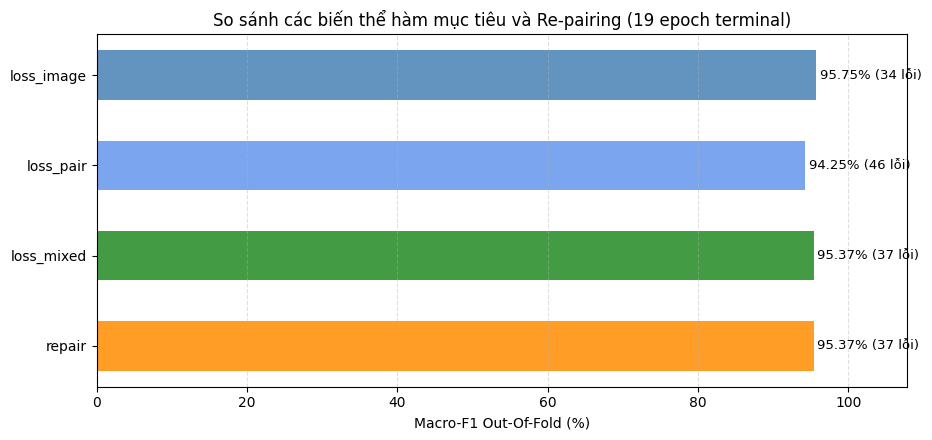

In [5]:
plt.figure(figsize=(9.5, 4.5))

loss_names = table_loss['name'].tolist()
f1_scores = (table_loss['macro_f1'] * 100.0).tolist()
error_counts = table_loss['errors'].tolist()

bar_colors = ['steelblue', 'cornflowerblue', 'forestgreen', 'darkorange']
y_coords = np.arange(len(loss_names))

plt.barh(y_coords, f1_scores, color=bar_colors, alpha=0.85, height=0.55)
plt.yticks(y_coords, [n.replace('_smoke', '') for n in loss_names])
plt.xlabel("Macro-F1 Out-Of-Fold (%)")
plt.title(f"So sánh các biến thể hàm mục tiêu và Re-pairing ({'Chế độ Smoke' if KMD_SMOKE else '19 epoch terminal'})")
plt.gca().invert_yaxis()

for idx, (f1_v, err_v) in enumerate(zip(f1_scores, error_counts)):
    plt.text(f1_v + 0.5, idx, f"{f1_v:.2f}% ({err_v} lỗi)", va='center', fontsize=9.5)

plt.xlim(0, max(f1_scores) + 12)
plt.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Diễn giải phép ghép cặp lại

Nếu `repair` tốt hơn `loss_mixed`, thử ghép lại có lợi trong giao thức này. Nếu không, giữ cặp gốc làm phương án đơn giản hơn. Ở cả hai trường hợp, chưa thể khẳng định mô hình đã ghi nhớ cặp hay mất ngữ cảnh: cần xem các ca đổi dự đoán và thử thêm seed để kiểm tra cách giải thích đó.

Số ảnh duy nhất vẫn giữ nguyên. Từ đây nảy sinh phép thử khác ở [Phụ lục C](extension_c_data_scaling.ipynb): cho mô hình tiếp xúc với nhiều ảnh khác nhau hơn, giữ số lần cập nhật bằng nhau.

## 4. Ghi nhận sau phép thử

Ghi loss nào có F1 cao nhất và log loss thấp nhất; hai tiêu chí có thể không chọn cùng một cấu hình. Pair loss trực tiếp học thứ tự cặp, nhưng điều đó không bảo đảm nó thắng Image loss. Với re-pairing, ghi chênh lệch so với `loss_mixed` để tách tác động ghép cặp khỏi tác động đổi loss.